## Data generating process
In this Notebook we will take a look at the data generating process that was discussed in the lecture. 

This Notebook is more "follow along and watch it unfold" then do-it-yourself, but feel free to try-out and adjust the code to your liking.


In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels as sms
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.stattools import adfuller

from scipy import signal
%matplotlib inline

# If you want a style choose one
#plt.style.use('Solarize_Light2')
#plt.style.use('tableau-colorblind10')
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'

In [2]:
def plot_ts(ts = None, ts_add = None, title ='Time Series', legend=['1']):
    """
    Plots one or two time series in a single plot
    
        Args:
        ts: 1d- or 2d-array of time series. Dimension
            must be (n,) or (n,2)
        title: Title for the time plot.
        legend: list of legend names. If empty no legend.
        
        Returns:
        matplotlib plot object
    """
    plt.figure(figsize=(10, 4))
    plt.plot(ts[:,], color=NF_ORANGE)
    plt.grid(True,axis='y')
    plt.title(title)
    if ts_add is not None:
        plt.plot(ts_add, color=NF_BLUE)
    if len(legend) > 0:
        plt.legend(legend)
    plt.savefig('temp.png',dpi=300)
    plt.show()

def plot_acf_pacf(ts, lags=10, layout='h'):
    """
    Plots the empirical ACF and PACF of a time series process.
    
        Args:
        ts: array of time series
        
        Returns:
        matplotlib subplot with ACF and PACF
    """
    if layout == 'h':
        fig, ax = plt.subplots(1, 2, figsize = (16,4))
    else: 
        fig, ax = plt.subplots(2, 1, figsize = (16,4))
    sm.tsa.graphics.plot_acf(ts,color = NF_ORANGE,lags=lags, ax = ax[0])
    sm.tsa.graphics.plot_pacf(ts,color = NF_ORANGE, lags = lags, ax = ax[1])    



def diff_series(ts, interval=1):
    """
    Differences a time series by a certain lag.
    
        Args:
        ts: array of 1d time series
        
        Returns:
        Differenced time series
    """
    diff = ts[interval:] - ts[:-interval]
    return diff

def kpss_test(ts):
    """
    Performs a KPSS test for the null hypothesis of stationarity.
    
        Args:
        ts: 1d time series
        
        Returns:
        Summary of test statistic and critical values
    """
    print ('Results of KPSS Test:')
    kpsstest = kpss(ts, regression='c', nlags='legacy')
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)'%key] = value
    print (kpss_output)

def adf_test(ts):
    """
    Performs a Dickey-Fuller test for the null hypothesis of
    non-stationarity.
    
        Args:
        ts: 1-d time series
    
        Returns:
        Printed test statistic and critical values.
    """
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(ts, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used',
                                             'Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

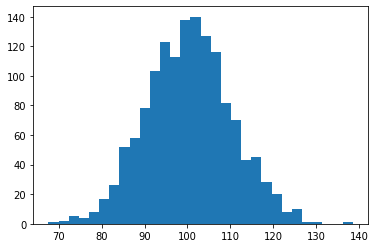

In [3]:
# Start by Gernerating the random series; Normaly distributed with mu=100 and sig=10
np.random.seed(42)
data = np.random.normal(100, 10, 1420)
plt.hist(data, bins=30)
plt.show()

Now we use a direct implementation of the rules discusses in the presentation for the Cake-store. The first two values are given to avoid index out of bounds errors.

In [4]:
#We start with some inital values to avoid NANs generated by the shift
stock_today=[250,250] 
stock_today=[0,0] 
prod_YesterOneday=[0,0]
prod_YesterTwoDay=[0,0]
picked_yesterOnedaysProd=[0,0]
picked_yesterTwodaysProd=[0,0] 
eaten=[0,0]
prod_Today=[0,100]

for dat in data:
    prod_YesterOneday.append(prod_Today[-1])
    prod_YesterTwoDay.append(prod_Today[-2])
    prod_Today.append(dat)
    picked_yesterOnedaysProd.append(prod_YesterOneday[-1]*0.4)
    picked_yesterTwodaysProd.append(prod_YesterTwoDay[-1]*0.2)
    eaten.append(stock_today[-1]*0.15)
    stock_today.append(stock_today[-1]
                       -eaten[-1]
                       +prod_Today[-1]
                       -picked_yesterOnedaysProd[-1]
                       -picked_yesterTwodaysProd[-1])
    
df=pd.DataFrame(data={'prod_Today':prod_Today,
                      'prod_YesterOneday':prod_YesterOneday,
                      'prod_YesterTwoDay':prod_YesterTwoDay,
                      'picked_yesterOnedaysProd':picked_yesterOnedaysProd,
                      'picked_yesterTwodaysProd':picked_yesterTwodaysProd,
                      'eaten':eaten,
                      'stock_today':stock_today})
df=df.iloc[2:].reset_index(drop=True)

Now let's have a look at the data

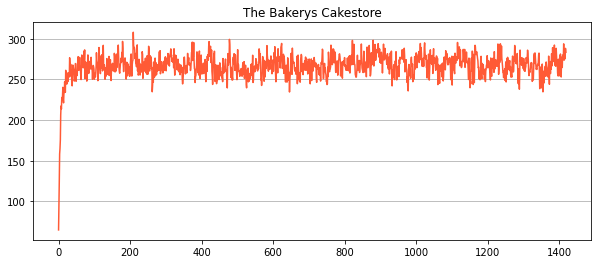

In [5]:
plot_ts(df.stock_today,title="The Bakerys Cakestore",legend=[])

As we can see, for the first timesteps there is an increase in stored cake. Afterwards it seems to stabilize at about 260 cake in stock. For this example the first observations dont really matter, so we throw them out and check for stationarity afterwards.

In [6]:
df=df.iloc[20:].reset_index(drop=True)
df.head(20)

,prod_Today,prod_YesterOneday,prod_YesterTwoDay,picked_yesterOnedaysProd,picked_yesterTwodaysProd,eaten,stock_today
0,114.656488,85.876963,90.919759,34.350785,18.183952,35.143079,261.265864
1,97.742237,114.656488,85.876963,45.862595,17.175393,39.189880,256.780234
2,100.675282,97.742237,114.656488,39.096895,22.931298,38.517035,256.910288
3,85.752518,100.675282,97.742237,40.270113,19.548447,38.536543,244.307703
4,94.556173,85.752518,100.675282,34.301007,20.135056,36.646155,247.781657
5,101.109226,94.556173,85.752518,37.822469,17.150504,37.167248,256.750661
6,88.490064,101.109226,94.556173,40.443690,18.911235,38.512599,247.373201
7,103.756980,88.490064,101.109226,35.396026,20.221845,37.105980,258.406330
8,93.993613,103.756980,88.490064,41.502792,17.698013,38.760950,254.438189
9,97.083063,93.993613,103.756980,37.597445,20.751396,38.165728,255.006682


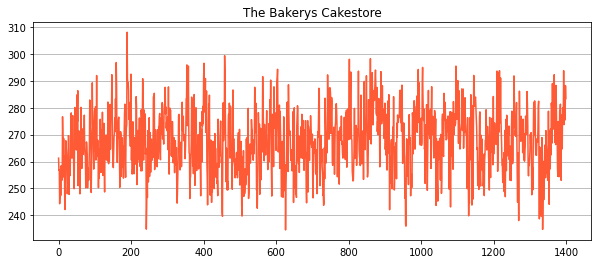

In [7]:
plot_ts(df.stock_today,title="The Bakerys Cakestore",legend=[])

Now it looks roughly stationary, but lets use some tests to make sure:

In [8]:
kpss_test(df.stock_today)

Results of KPSS Test:
Test Statistic            0.326459
p-value                   0.100000
Lags Used                24.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


/Users/nicosteffen/Desktop/neuefische/test/ds-time-series/.venv/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2002: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


In [9]:
adf_test(df.stock_today)

Results of Dickey-Fuller Test:
Test Statistic                -1.168173e+01
p-value                        1.734898e-21
#Lags Used                     4.000000e+00
Number of Observations Used    1.395000e+03
Critical Value (1%)           -3.435046e+00
Critical Value (5%)           -2.863614e+00
Critical Value (10%)          -2.567874e+00
dtype: float64


Both tests indicate stationariy so we can resume to try and model the signal with an ARIMA process. From the presentation we already know, that 2 MA and 1 AR terms are used, hence, we use a (1,0,2) ARIMA model.

In [10]:
#Use the 10 most recent values for testing
train,test = df.stock_today[:-15],df.stock_today[-15:]

#Train the model
mod = sms.tsa.arima.model.ARIMA(train, order=(1, 0, 2),)
res = mod.fit()
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:            stock_today   No. Observations:                 1385
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -5137.375
Date:                Wed, 17 Nov 2021   AIC                          10284.749
Time:                        20:17:44   BIC                          10310.917
Sample:                             0   HQIC                         10294.536
                               - 1385                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        267.5767      0.719    372.326      0.000     266.168     268.985
ar.L1          0.8560      0.039     22.128      0.000       0.780       0.932
ma.L1         -0.4206      0.050     -8.415      0.0

All values show a statistical significance. The Model returns a good estimation for the coefficients: theoretically these should have been:
* ar.L1=0.85
* ma.L1=-0.4
* ma.L2=-0.2

But keep in mind, we only provide the model with the number of cakes in the store and the *order* of the arma process. The weights were computed automatically and correctly.  


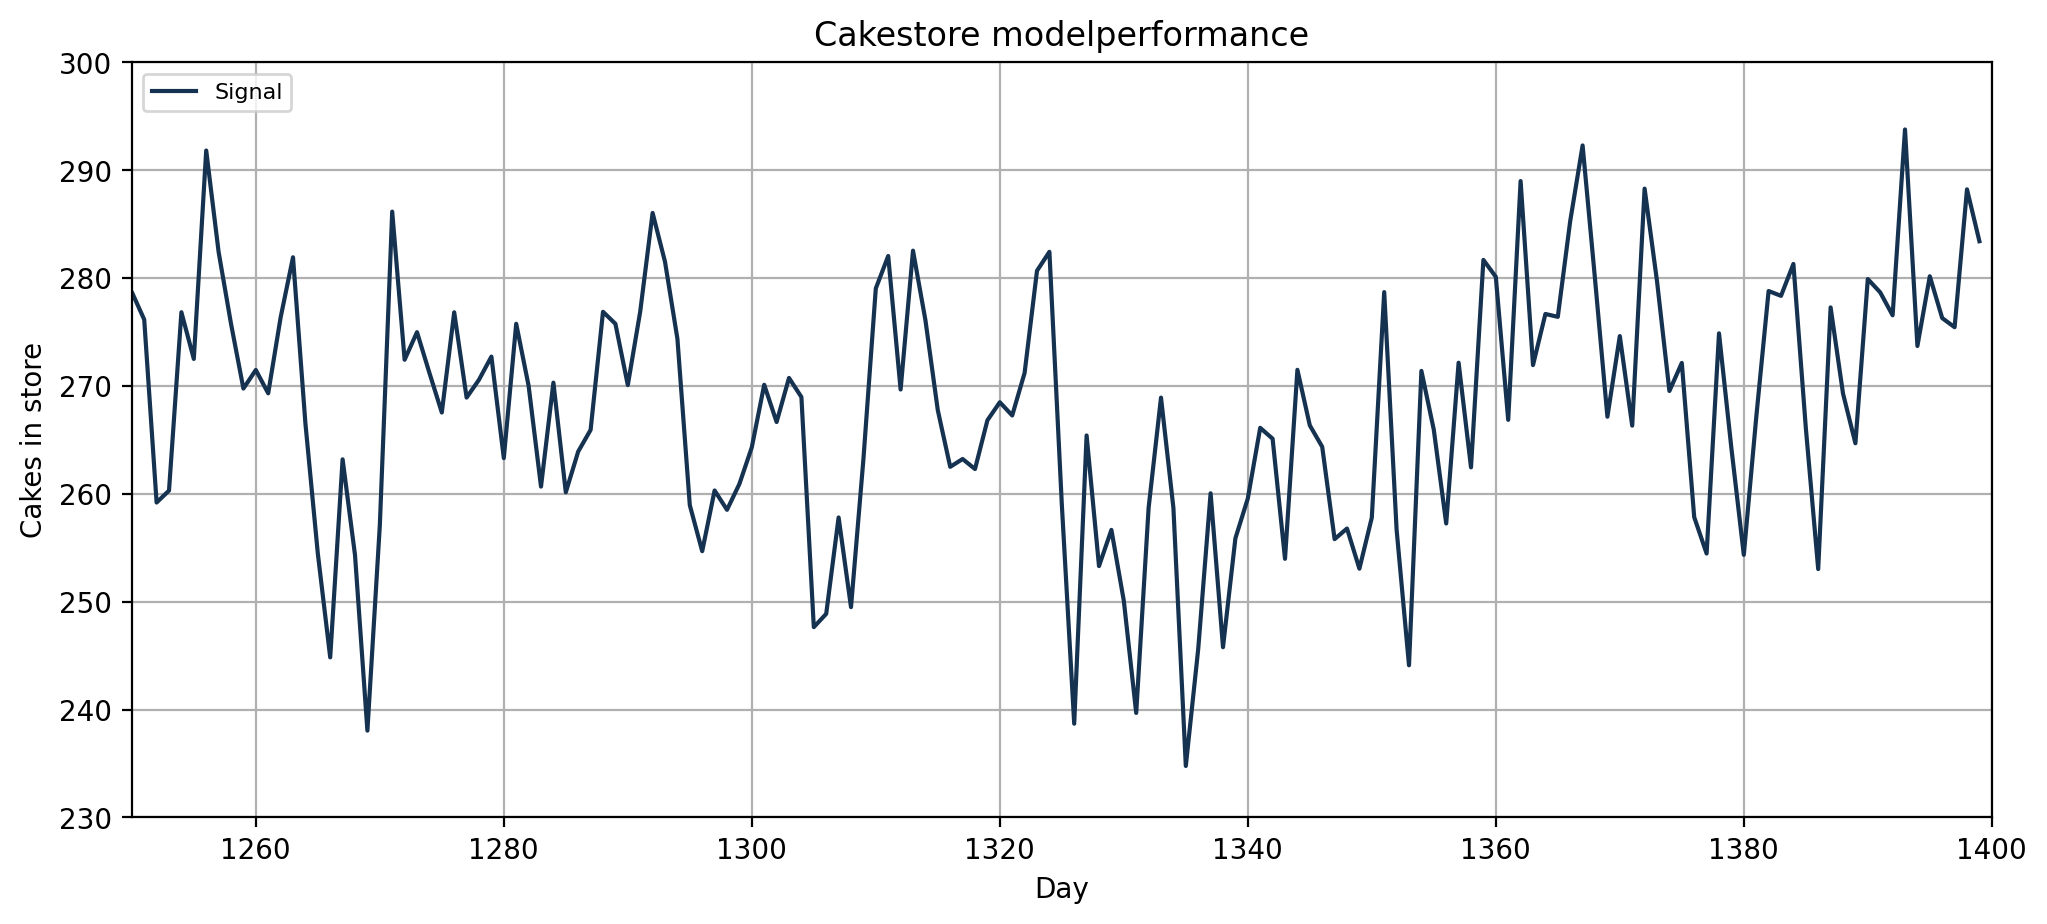

In [13]:
# Forecasting values

# Plot the predicted stock price and original price
fig,ax = plt.subplots(1,1,figsize=(12,5), dpi=200)
plt.plot(df.stock_today, label='Signal',color=NF_BLUE)


plt.title('Cakestore modelperformance')
plt.xlabel('Day')
plt.ylabel('Cakes in store')
plt.legend(loc='upper left', fontsize=8)
plt.xlim(1250,1400)
plt.ylim(230,300)
ax.grid()
fig.savefig('Cake_Prediction1.png')
plt.show()


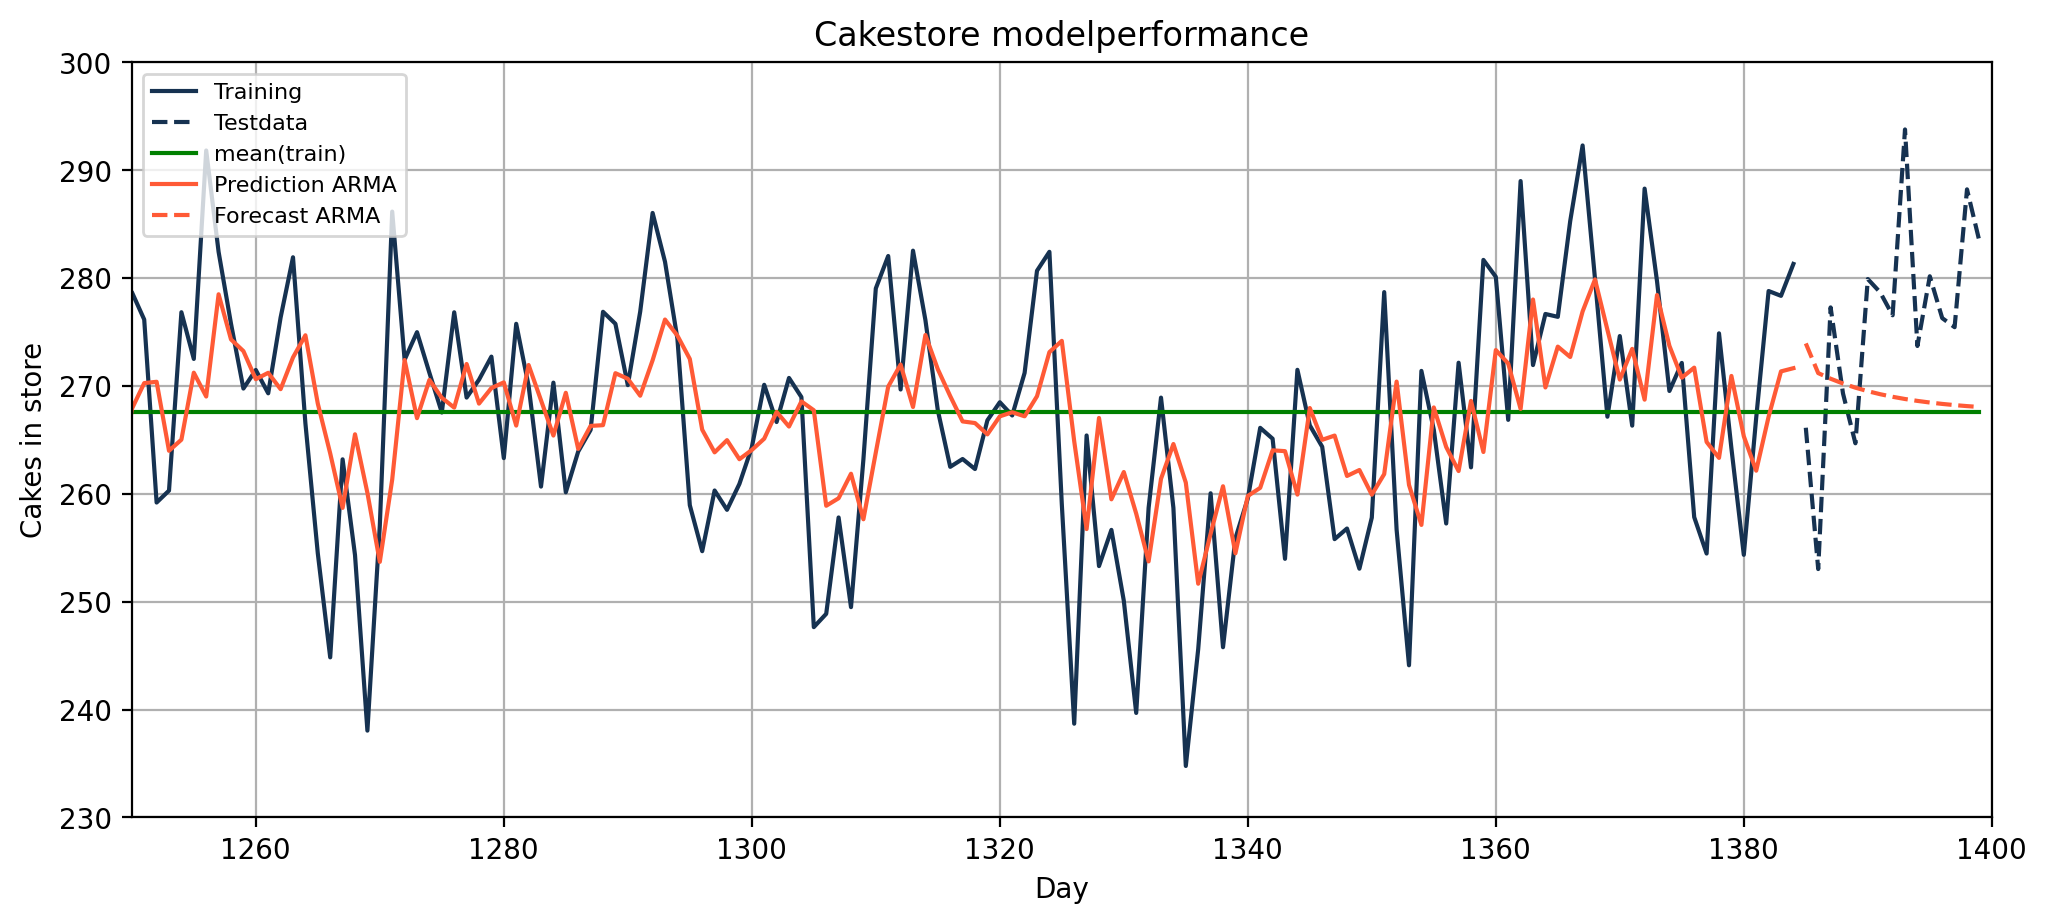

Train RMSE of predict_mean: 11.32
Train RMSE of predict_ARMA: 9.88
Test RMSE of predict_mean: 12.58
Test RMSE of predict_ARMA: 12.27


In [14]:
# Forecasting values

in_series_prediction= res.predict() 
forecast_values =res.forecast(15)

pv_series = pd.Series(in_series_prediction, index=train.index)
fcv_series = pd.Series(forecast_values, index=test.index)

# Plot the predicted stock price and original price
fig,ax = plt.subplots(1,1,figsize=(12,5), dpi=200)
plt.plot(train, label='Training',color=NF_BLUE)
plt.plot(test, '--',label='Testdata',color=NF_BLUE)
plt.plot(mean_pred:=[train.mean()]*(len(train)+len(test)), label='mean(train)',color="green")
plt.plot(pv_series,label='Prediction ARMA',color=NF_ORANGE)
plt.plot(fcv_series,'--',label='Forecast ARMA',color=NF_ORANGE)

plt.title('Cakestore modelperformance')
plt.xlabel('Day')
plt.ylabel('Cakes in store')
#plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
plt.xlim(1250,1400)
plt.ylim(230,300)
ax.grid()
fig.savefig('Cake_Prediction2.png')
plt.show()

RMSE_mean_train=np.sqrt(np.mean((mean_pred[:-15]-train)**2))
RMSE_ARMA_train=np.sqrt(np.mean((pv_series-train)**2))
print(f"Train RMSE of predict_mean: {round(RMSE_mean_train,2)}")
print(f"Train RMSE of predict_ARMA: {round(RMSE_ARMA_train,2)}")

RMSE_mean_test=np.sqrt(np.mean(([train.mean()]*15-test)**2))
RMSE_ARMA_test=np.sqrt(np.mean((forecast_values-test)**2))
print(f"Test RMSE of predict_mean: {round(RMSE_mean_test,2)}")
print(f"Test RMSE of predict_ARMA: {round(RMSE_ARMA_test,2)}")

As we can see, the RMSE on the in-series (trainset) prediction is better then the naive approach of just predicting the mean. For the forecasted values (test-set), there is only a marginal improvement.  